In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import mlflow
import mlflow.lightgbm

In [21]:
data = pd.read_pickle('../data/processed/epias_feature_engineered.pkl')
data.head()

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,Rolling_Mean_24,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_1,Lag_24,Lag_168
2024-01-14 23:00:00,14.01.2024,23:00,2099.01,1800.00,1746.00,2161.98,Enerji Fazlası,1,Sunday,winter,2217.692083,373.580131,2050.143869,0,1,2245.00,2244.99,129.99
2024-01-15 00:00:00,15.01.2024,00:00,2149.01,1650.12,1600.62,2213.48,Enerji Fazlası,1,Monday,winter,2203.067917,368.889105,2061.298690,0,0,2099.01,2499.99,275.00
2024-01-15 01:00:00,15.01.2024,01:00,1248.99,700.00,679.00,1286.46,Enerji Fazlası,1,Monday,winter,2163.859167,417.186176,2067.959405,0,0,2149.01,2190.00,129.99
2024-01-15 02:00:00,15.01.2024,02:00,1188.88,940.88,912.65,1224.55,Enerji Fazlası,1,Monday,winter,2122.521667,462.145250,2074.351488,0,0,1248.99,2180.98,115.01
2024-01-15 03:00:00,15.01.2024,03:00,1188.88,1183.88,1148.36,1224.55,Enerji Fazlası,1,Monday,winter,2109.558333,484.203502,2080.768274,0,0,1188.88,1500.00,110.86


In [22]:
data["Lag_48"] = data["PTF"].shift(48)
data["Lag_72"] = data["PTF"].shift(72)
data["Lag_96"] = data["PTF"].shift(96)

data.head()

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,...,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_1,Lag_24,Lag_168,Lag_48,Lag_72,Lag_96
2024-01-14 23:00:00,14.01.2024,23:00,2099.01,1800.00,1746.00,2161.98,Enerji Fazlası,1,Sunday,winter,...,373.580131,2050.143869,0,1,2245.00,2244.99,129.99,NaN,NaN,NaN
2024-01-15 00:00:00,15.01.2024,00:00,2149.01,1650.12,1600.62,2213.48,Enerji Fazlası,1,Monday,winter,...,368.889105,2061.298690,0,0,2099.01,2499.99,275.00,NaN,NaN,NaN
2024-01-15 01:00:00,15.01.2024,01:00,1248.99,700.00,679.00,1286.46,Enerji Fazlası,1,Monday,winter,...,417.186176,2067.959405,0,0,2149.01,2190.00,129.99,NaN,NaN,NaN
2024-01-15 02:00:00,15.01.2024,02:00,1188.88,940.88,912.65,1224.55,Enerji Fazlası,1,Monday,winter,...,462.145250,2074.351488,0,0,1248.99,2180.98,115.01,NaN,NaN,NaN
2024-01-15 03:00:00,15.01.2024,03:00,1188.88,1183.88,1148.36,1224.55,Enerji Fazlası,1,Monday,winter,...,484.203502,2080.768274,0,0,1188.88,1500.00,110.86,NaN,NaN,NaN


In [23]:
data[data["Lag_96"].isnull()]

,Tarih,Saat,PTF,SMF,Pozitif Dengesizlik Fiyatı (TL/MWh),Negatif Dengesizlik Fiyatı (TL/MWh),SMF Yön,month,day,season,...,Rolling_Std_24,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_1,Lag_24,Lag_168,Lag_48,Lag_72,Lag_96
2024-01-14 23:00:00,14.01.2024,23:00,2099.01,1800.00,1746.00,2161.98,Enerji Fazlası,1,Sunday,winter,...,373.580131,2050.143869,0,1,2245.00,2244.99,129.99,NaN,NaN,NaN
2024-01-15 00:00:00,15.01.2024,00:00,2149.01,1650.12,1600.62,2213.48,Enerji Fazlası,1,Monday,winter,...,368.889105,2061.298690,0,0,2099.01,2499.99,275.00,NaN,NaN,NaN
2024-01-15 01:00:00,15.01.2024,01:00,1248.99,700.00,679.00,1286.46,Enerji Fazlası,1,Monday,winter,...,417.186176,2067.959405,0,0,2149.01,2190.00,129.99,NaN,NaN,NaN
2024-01-15 02:00:00,15.01.2024,02:00,1188.88,940.88,912.65,1224.55,Enerji Fazlası,1,Monday,winter,...,462.145250,2074.351488,0,0,1248.99,2180.98,115.01,NaN,NaN,NaN
2024-01-15 03:00:00,15.01.2024,03:00,1188.88,1183.88,1148.36,1224.55,Enerji Fazlası,1,Monday,winter,...,484.203502,2080.768274,0,0,1188.88,1500.00,110.86,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-18 18:00:00,18.01.2024,18:00,2589.99,1901.00,1843.97,2667.69,Enerji Fazlası,1,Thursday,winter,...,558.002468,2156.440952,0,0,2687.10,2700.00,2700.00,2649.00,2649.00,NaN
2024-01-18 19:00:00,18.01.2024,19:00,2050.00,2040.00,1978.80,2111.50,Enerji Fazlası,1,Thursday,winter,...,545.209989,2152.889226,0,0,2589.99,2674.92,2646.69,2489.99,2327.82,NaN
2024-01-18 20:00:00,18.01.2024,20:00,2100.00,2100.00,2037.00,2163.00,Enerji Açığı,1,Thursday,winter,...,538.192128,2149.913155,0,0,2050.00,2499.99,2599.98,2299.99,2375.00,NaN
2024-01-18 21:00:00,18.01.2024,21:00,2100.00,2000.00,1940.00,2163.00,Enerji Fazlası,1,Thursday,winter,...,533.999814,2147.770357,0,0,2100.00,2390.24,2459.99,2416.22,2415.31,NaN


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16957 entries, 2024-01-14 23:00:00 to 2025-12-20 11:00:00
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Tarih                                16957 non-null  object  
 1   Saat                                 16957 non-null  object  
 2   PTF                                  16957 non-null  float64 
 3   SMF                                  16957 non-null  float64 
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  16957 non-null  float64 
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  16957 non-null  float64 
 6   SMF Yön                              16957 non-null  object  
 7   month                                16957 non-null  category
 8   day                                  16957 non-null  category
 9   season                               16957 non-null  category
 10  Rolling_Mean_24                      16957 non-

In [25]:
data.dropna(subset=['Lag_24', 'Lag_48', 'Lag_72', 'Lag_96', 'Lag_168'], inplace=True)

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16861 entries, 2024-01-18 23:00:00 to 2025-12-20 11:00:00
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Tarih                                16861 non-null  object  
 1   Saat                                 16861 non-null  object  
 2   PTF                                  16861 non-null  float64 
 3   SMF                                  16861 non-null  float64 
 4   Pozitif Dengesizlik Fiyatı (TL/MWh)  16861 non-null  float64 
 5   Negatif Dengesizlik Fiyatı (TL/MWh)  16861 non-null  float64 
 6   SMF Yön                              16861 non-null  object  
 7   month                                16861 non-null  category
 8   day                                  16861 non-null  category
 9   season                               16861 non-null  category
 10  Rolling_Mean_24                      16861 non-

In [29]:
# 1. Geleceği Gören (Data Leakage) Sütunları Belirle
leakage_cols = [
    'Lag_1',                              # 1 saat öncesi (Yasak)
    'SMF',                                # Gelecek verisi (Yasak)
    'Pozitif Dengesizlik Fiyatı (TL/MWh)', # Gelecek verisi (Yasak)
    'Negatif Dengesizlik Fiyatı (TL/MWh)', # Gelecek verisi (Yasak)
    'SMF Yön',                            # Gelecek verisi (Yasak)
    'Rolling_Mean_24',                    # Dikkat: Bu Lag_1 içeriyorsa yasaktır! (Genelde içerir, silelim)
    'Rolling_Std_24'                      # Bu da Lag_1 içerir
]

# 2. Sütunlar veride var mı kontrol et ve sil
cols_to_drop = [col for col in leakage_cols if col in data.columns]

print(f" Silinecek Yasaklı Sütunlar: {cols_to_drop}")

# Veriden atıyoruz
data = data.drop(columns=cols_to_drop)

# Tarih ve Saat sütunları object (string) kalmış, model bunları sevmez.
# Zaten indexte tarih var, month/day/season kategorik var.
# 'Tarih' ve 'Saat' sütunlarını da atabiliriz (Gereksiz tekrar).
unnecessary_cols = ['Tarih', 'Saat']
cols_to_drop_2 = [col for col in unnecessary_cols if col in data.columns]
data = data.drop(columns=cols_to_drop_2)

print("-" * 30)
print(f"✅ TEMİZLİK BİTTİ!")
print(f"📦 Kalan Sütun Sayısı: {data.shape[1]}")
print(f"📋 Kalan Sütunlar: {data.columns.tolist()}")

 Silinecek Yasaklı Sütunlar: ['Lag_1', 'SMF', 'Pozitif Dengesizlik Fiyatı (TL/MWh)', 'Negatif Dengesizlik Fiyatı (TL/MWh)', 'SMF Yön', 'Rolling_Mean_24', 'Rolling_Std_24']
------------------------------
✅ TEMİZLİK BİTTİ!
📦 Kalan Sütun Sayısı: 12
📋 Kalan Sütunlar: ['PTF', 'month', 'day', 'season', 'Rolling_Mean_168', 'Is_Holiday', 'Is_Weekend', 'Lag_24', 'Lag_168', 'Lag_48', 'Lag_72', 'Lag_96']


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16861 entries, 2024-01-18 23:00:00 to 2025-12-20 11:00:00
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   PTF               16861 non-null  float64 
 1   month             16861 non-null  category
 2   day               16861 non-null  category
 3   season            16861 non-null  category
 4   Rolling_Mean_168  16861 non-null  float64 
 5   Is_Holiday        16861 non-null  category
 6   Is_Weekend        16861 non-null  category
 7   Lag_24            16861 non-null  float64 
 8   Lag_168           16861 non-null  float64 
 9   Lag_48            16861 non-null  float64 
 10  Lag_72            16861 non-null  float64 
 11  Lag_96            16861 non-null  float64 
dtypes: category(5), float64(7)
memory usage: 1.1 MB


In [31]:
data['Hour'] = data.index.hour
data['DayOfWeek'] = data.index.dayofweek  # 0: Pzt, 6: Paz

In [32]:
data.head()

,PTF,month,day,season,Rolling_Mean_168,Is_Holiday,Is_Weekend,Lag_24,Lag_168,Lag_48,Lag_72,Lag_96,Hour,DayOfWeek
2024-01-18 23:00:00,1233.61,1,Thursday,winter,2136.612798,0,0,2193.99,2146.01,2287.23,1056.99,2099.01,23,3
2024-01-19 00:00:00,1232.61,1,Friday,winter,2129.068810,0,0,2302.00,2500.00,2199.99,1449.99,2149.01,0,4
2024-01-19 01:00:00,1232.61,1,Friday,winter,2122.715238,0,0,2245.00,2300.01,2194.00,1248.98,1248.99,1,4
2024-01-19 02:00:00,1232.61,1,Friday,winter,2117.099821,0,0,1248.98,2176.00,2138.34,1057.00,1188.88,2,4
2024-01-19 03:00:00,900.00,1,Friday,winter,2109.665298,0,0,1248.98,2149.00,2099.99,1000.01,1188.88,3,4


In [33]:
split_date = '2025-10-01'

train = data.loc[data.index < split_date].copy()
test = data.loc[data.index >= split_date].copy()

In [35]:
train.shape[0] , test.shape[0]

(14929, 1932)

In [36]:
X_train = train.drop(columns=['PTF'])
y_train = train['PTF']

X_test = test.drop(columns=['PTF'])
y_test = test['PTF']

In [38]:
mlflow.set_experiment("gop_modelling")
with mlflow.start_run(run_name="gop_model_1"):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'n_estimators': 5000,     # Uzun uzun düşünsün
        'learning_rate': 0.02,    # Yavaş öğrensin, ezberlemesin
        'num_leaves': 45,         # Dalları biraz uzatalım
        'colsample_bytree': 0.8,  # Her ağaçta özelliklerin %80'ine baksın (Çeşitlilik)
        'random_state': 44,
        'n_jobs': -1,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    
    # EĞİTİM (Test setini sadece izlemesi için veriyoruz, öğrenmesi için değil)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    preds = model.predict(X_test)
    
    # METRİKLER
    wmape = np.sum(np.abs(y_test - preds)) / np.sum(y_test) * 100
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    mlflow.log_params(params)
    mlflow.log_metric("wmape", wmape)
    mlflow.log_metric("mae", mae)
    
    
    print(f"FİNAL SONUÇ ")
    print(f"WMAPE : %{wmape:.2f}")
    print(f"MAE   : {mae:.2f} TL")
    print(f"R2    : {r2:.4f}")
  


FİNAL SONUÇ 
WMAPE : %10.57
MAE   : 297.03 TL
R2    : 0.6139


Yorumlayalım ; 
wmape : %10 yanılma ile tahminliyoruz.
mae   : ortalama 297tl sapmamız var
r2    : Fiyattaki dalgalanmaların %61'ini açıklayabiliyorum, %39'u ise benim için sürpriz. Bence kötü buna bakıcaz.

C:\Users\90546\AppData\Local\Temp\ipykernel_32532\1698214703.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=feature_imp, palette="viridis")


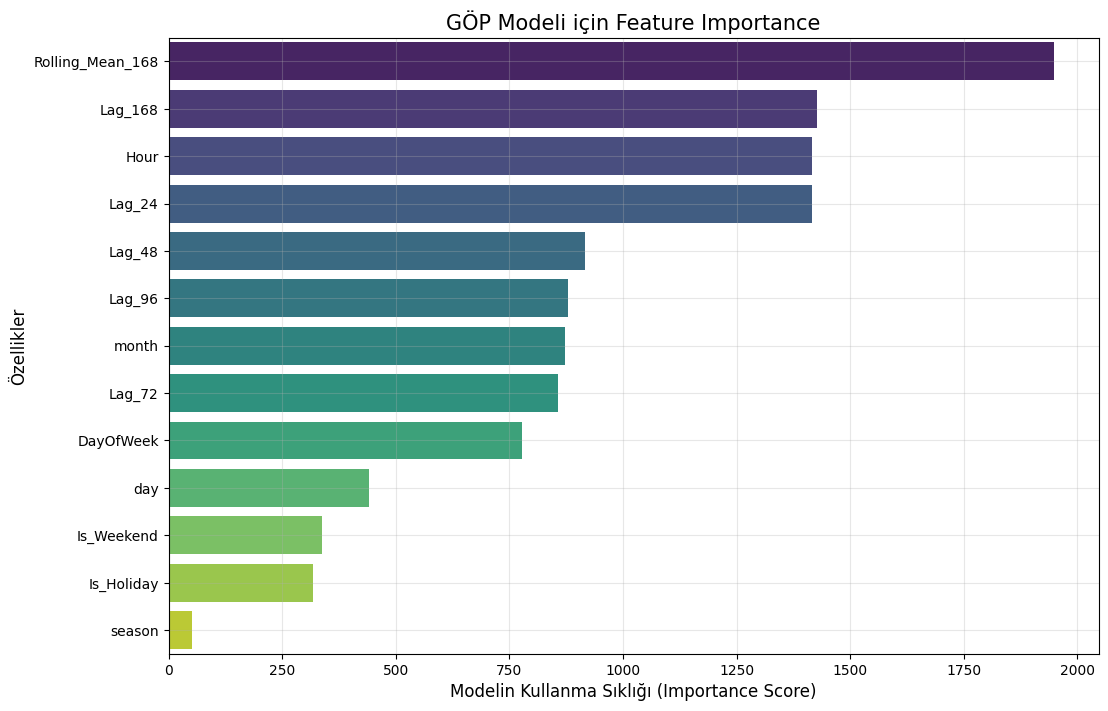

In [41]:
feature_imp = pd.DataFrame(sorted(zip(model.feature_importances_, X_train.columns)), columns=['Value','Feature'])
feature_imp = feature_imp.sort_values(by="Value", ascending=False)


plt.figure(figsize=(12, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp, palette="viridis")
plt.title('GÖP Modeli için Feature Importance', fontsize=15)
plt.xlabel('Modelin Kullanma Sıklığı (Importance Score)', fontsize=12)
plt.ylabel('Özellikler', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


overfit var mı  : test train hata grafiği yapalım.

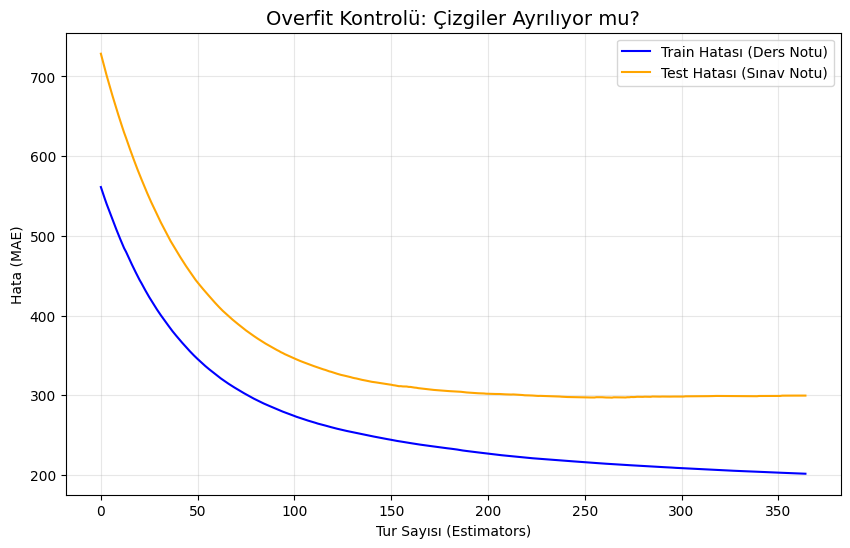

Son Train Hatası: 201.58
Son Test Hatası : 299.61


In [47]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# 1. Modeli Tanımla
params = {
    'objective': 'regression',
    'metric': 'mae',
    'n_estimators': 5000,     # Uzun bir yolculuk
    'learning_rate': 0.02,
    'num_leaves': 45,
    'colsample_bytree': 0.8,
    'random_state': 44,
    'n_jobs': -1,
    'verbosity': -1
}

model_check = lgb.LGBMRegressor(**params)


# 2. Hem Train hem Test'i "İzleyici" olarak veriyoruz
# Model Train'den öğrenir, Test'e sadece "Bak bakalım notum kaç?" diye sorar.
model_check.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    eval_names=['Train', 'Test'],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)] # Notu düşmeye başlarsa dur!
)

# 3. Sonuçları (Her turun hatasını) alıyoruz
results = model_check.evals_result_
epochs = len(results['Train']['l1']) # l1 = MAE
x_axis = range(0, epochs)

# 4. Grafiği Çiziyoruz
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['Train']['l1'], label='Train Hatası (Ders Notu)', color='blue')
plt.plot(x_axis, results['Test']['l1'], label='Test Hatası (Sınav Notu)', color='orange')
plt.title('Overfit Kontrolü: Çizgiler Ayrılıyor mu?', fontsize=14)
plt.xlabel('Tur Sayısı (Estimators)')
plt.ylabel('Hata (MAE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Yorum
print(f"Son Train Hatası: {results['Train']['l1'][-1]:.2f}")
print(f"Son Test Hatası : {results['Test']['l1'][-1]:.2f}")

METRİK     | TRAIN (Eğitim)  | TEST (Sınav)    | FARK (Gap)
MAE        | 213.65 TL        | 297.03 TL        | 83.38 TL
WMAPE      | %8.98          | %10.57          | %1.60
R2         | 0.8331          | 0.6139          | 0.2192


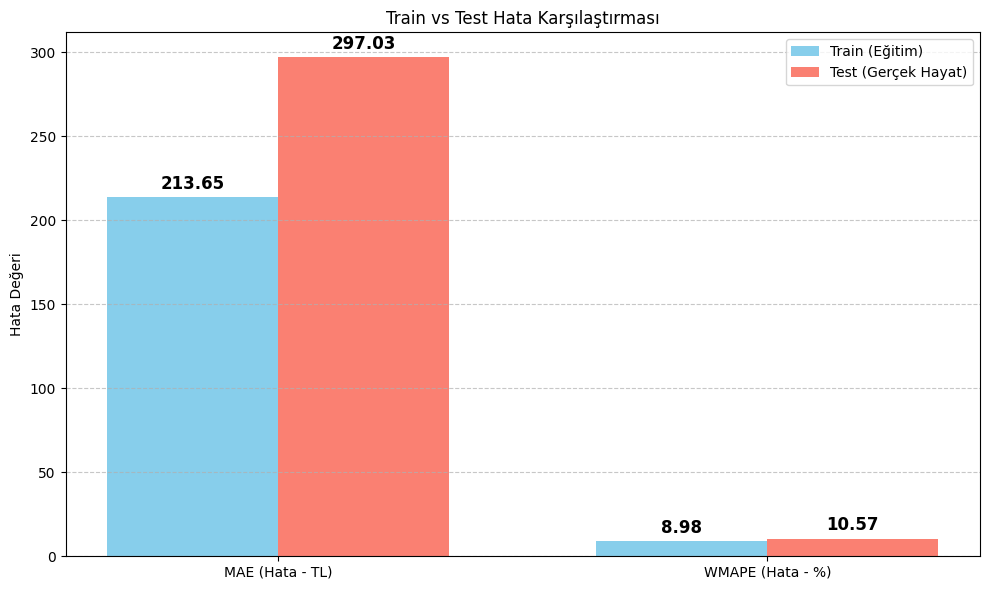

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score


# 1. Tahminleri Üret (Ayrı Ayrı)
# ---------------------------------------------------------
# Eğitim setini verip "Bakalım ne kadarını hatırlıyorsun?" diyoruz.
y_pred_train = model_check.predict(X_train)

# Test setini verip "Bakalım yeni sorularda nasılsın?" diyoruz.
y_pred_test = model_check.predict(X_test)

# 2. Metrikleri Hesapla (Ayrı Ayrı)
# ---------------------------------------------------------
# Train Metrikleri
mae_train = mean_absolute_error(y_train, y_pred_train)
wmape_train = np.sum(np.abs(y_train - y_pred_train)) / np.sum(y_train) * 100
r2_train = r2_score(y_train, y_pred_train)

# Test Metrikleri
mae_test = mean_absolute_error(y_test, y_pred_test)
wmape_test = np.sum(np.abs(y_test - y_pred_test)) / np.sum(y_test) * 100
r2_test = r2_score(y_test, y_pred_test)

# 3. Sonuçları Yazdır
# ---------------------------------------------------------

print(f"{'METRİK':<10} | {'TRAIN (Eğitim)':<15} | {'TEST (Sınav)':<15} | {'FARK (Gap)':<10}")
print("="*50)
print(f"{'MAE':<10} | {mae_train:.2f} TL        | {mae_test:.2f} TL        | {mae_test - mae_train:.2f} TL")
print(f"{'WMAPE':<10} | %{wmape_train:.2f}          | %{wmape_test:.2f}          | %{wmape_test - wmape_train:.2f}")
print(f"{'R2':<10} | {r2_train:.4f}          | {r2_test:.4f}          | {r2_train - r2_test:.4f}")


# 4. Grafiği Çiz (Bar Chart)
# ---------------------------------------------------------
metrics = ['MAE (Hata - TL)', 'WMAPE (Hata - %)']
train_scores = [mae_train, wmape_train]
test_scores = [mae_test, wmape_test]

x = np.arange(len(metrics))  # Etiketlerin konumu
width = 0.35  # Çubuk genişliği

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_scores, width, label='Train (Eğitim)', color='skyblue')
rects2 = ax.bar(x + width/2, test_scores, width, label='Test (Gerçek Hayat)', color='salmon')

# Süslemeler
ax.set_ylabel('Hata Değeri')
ax.set_title('Train vs Test Hata Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Çubukların üzerine değerleri yaz
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

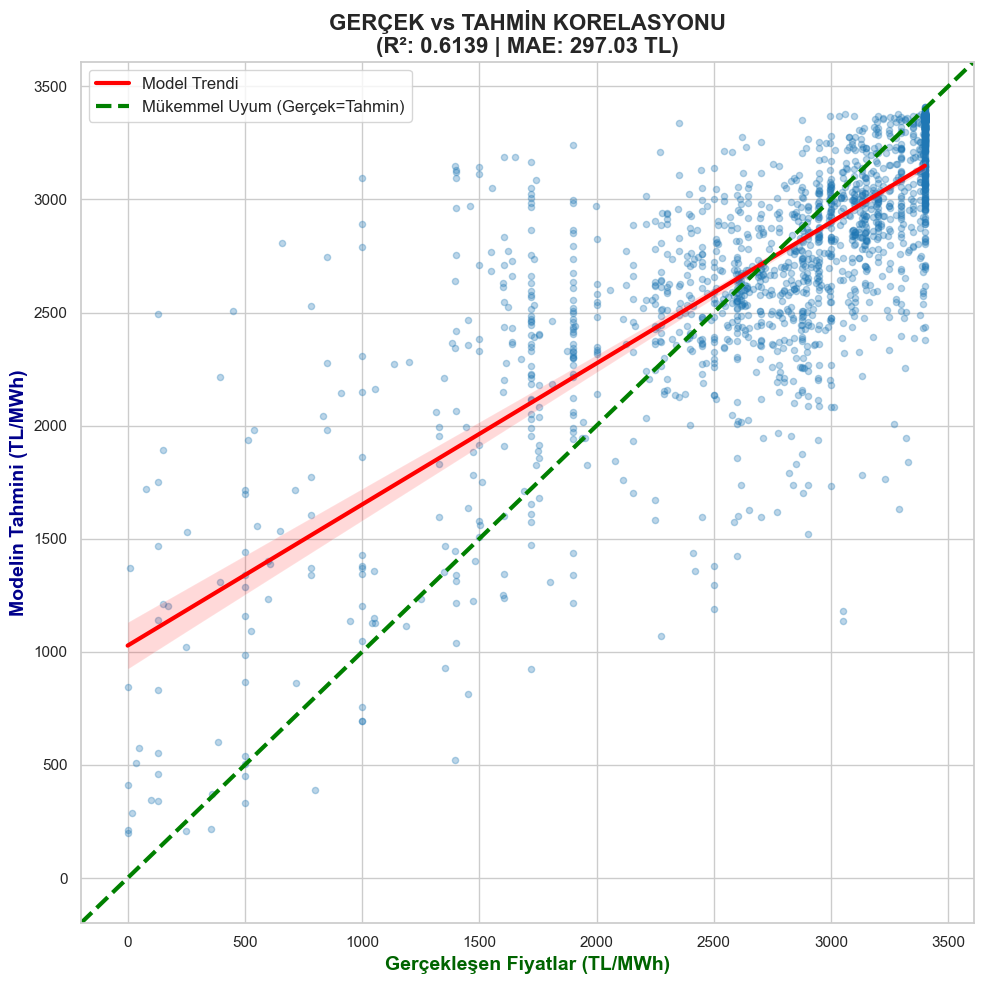

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np


# 1. Gerekli Verileri Hazırla
# (Eğer önceki adımlardan 'preds' değişkeni duruyorsa onu kullanır, yoksa tekrar hesaplar)
try:
    test_predictions = preds
except NameError:
    print("Tahminler bulunamadı, tekrar hesaplanıyor...")
    test_predictions = model_check.predict(X_test)

# Metrikleri hesapla (Grafik başlığına yazmak için)
r2_final = r2_score(y_test, test_predictions)
mae_final = mean_absolute_error(y_test, test_predictions)

# 2. Grafik Ayarları
plt.figure(figsize=(10, 10)) # Kare olması önemlidir (Kıyaslama için)
sns.set_theme(style="whitegrid") # Arka planı ızgaralı yap

# 3. Ana Saçılım Grafiği (Scatter Plot) ve Trend Çizgisi
# alpha=0.3 : Noktaları şeffaf yapar ki yoğunluk görünsün
# regplot : Hem noktaları hem de kırmızı trend çizgisini otomatik çizer
sns.regplot(x=y_test, y=test_predictions,
            scatter_kws={'alpha': 0.3, 's': 20, 'color': '#1f77b4'}, # Mavi şeffaf noktalar
            line_kws={'color': 'red', 'linewidth': 3, 'label': 'Model Trendi'}) # Kırmızı trend çizgisi

# 4. Mükemmel Uyum Çizgisi (Identity Line - y=x)
# Bu çizgi üzerindeki noktalar "Tam İsabet" demektir.
max_val = max(y_test.max(), test_predictions.max()) + 200 # Grafiğin tavanı
min_val = min(y_test.min(), test_predictions.min()) - 200 # Grafiğin tabanı
plt.plot([min_val, max_val], [min_val, max_val],
         color='green', linestyle='--', linewidth=3, label='Mükemmel Uyum (Gerçek=Tahmin)')

# 5. Etiketler ve Başlık
plt.title(f'GERÇEK vs TAHMİN KORELASYONU\n(R²: {r2_final:.4f} | MAE: {mae_final:.2f} TL)', fontsize=16, fontweight='bold')
plt.xlabel('Gerçekleşen Fiyatlar (TL/MWh)', fontsize=14, fontweight='bold', color='darkgreen')
plt.ylabel('Modelin Tahmini (TL/MWh)', fontsize=14, fontweight='bold', color='darkblue')

# Eksenleri eşitle ki kare görünsün (Daha doğru kıyaslama sağlar)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

------------------------------
Ortalama Hata (Bias): 29.12 TL (0'a ne kadar yakınsa o kadar iyi)
Standart Sapma      : 446.23 TL (Hatanın oynaklığı)
En Kötü Pozitif Hata: 1914.11 TL (Fiyat fırlamış, biz yakalayamamışız)
En Kötü Negatif Hata: -2362.81 TL (Biz uçmuşuz, fiyat düşük kalmış)
------------------------------


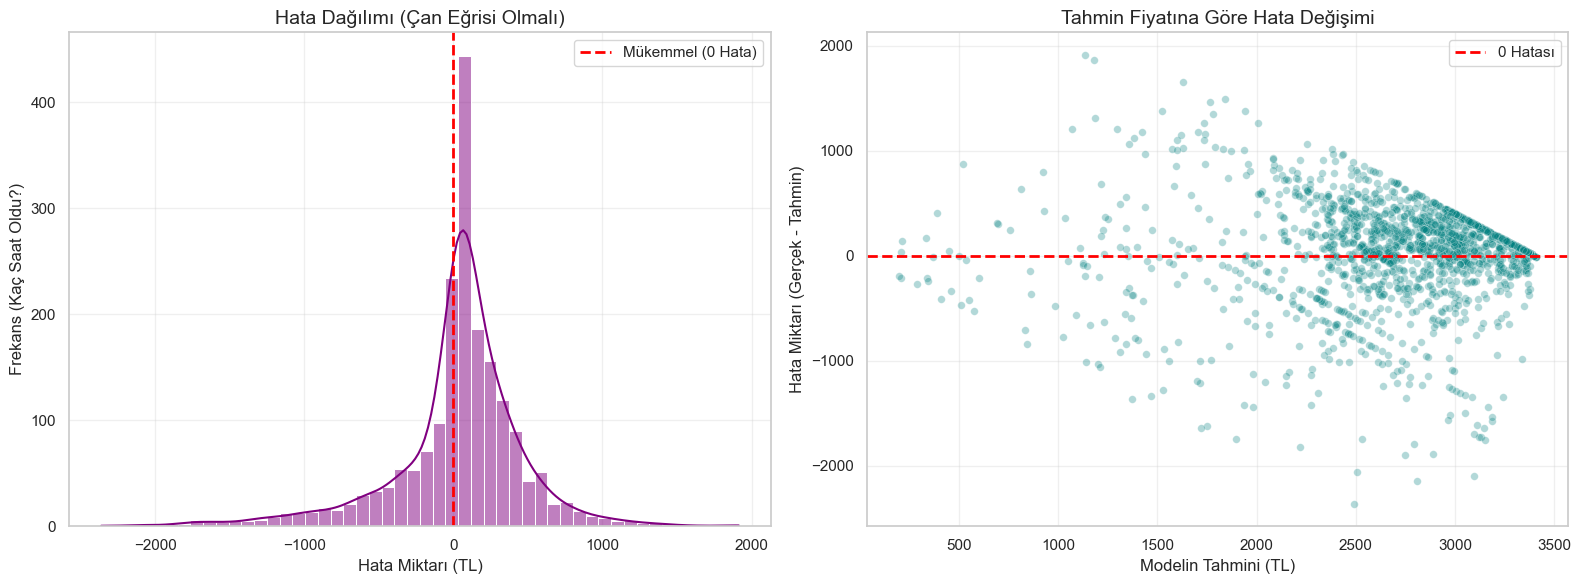

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Hataları (Residuals) Hesapla
# Hata = Gerçek - Tahmin
# Pozitif Hata: Model eksik tahmin etmiş (Gerçek 2000, Tahmin 1800 -> Hata +200)
# Negatif Hata: Model fazla atmış (Gerçek 1000, Tahmin 1200 -> Hata -200)
residuals = y_test - preds

# 2. İstatistiksel Özet

print("-" * 30)
print(f"Ortalama Hata (Bias): {np.mean(residuals):.2f} TL (0'a ne kadar yakınsa o kadar iyi)")
print(f"Standart Sapma      : {np.std(residuals):.2f} TL (Hatanın oynaklığı)")
print(f"En Kötü Pozitif Hata: {np.max(residuals):.2f} TL (Fiyat fırlamış, biz yakalayamamışız)")
print(f"En Kötü Negatif Hata: {np.min(residuals):.2f} TL (Biz uçmuşuz, fiyat düşük kalmış)")
print("-" * 30)

# 3. Grafikleri Çiz
plt.figure(figsize=(16, 6))

# --- GRAFİK 1: HATA DAĞILIMI (HISTOGRAM) ---
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mükemmel (0 Hata)')
plt.title('Hata Dağılımı (Çan Eğrisi Olmalı)', fontsize=14)
plt.xlabel('Hata Miktarı (TL)', fontsize=12)
plt.ylabel('Frekans (Kaç Saat Oldu?)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRAFİK 2: TAHMİN BÜYÜKLÜĞÜNE GÖRE HATA (RESIDUAL PLOT) ---
plt.subplot(1, 2, 2)
sns.scatterplot(x=preds, y=residuals, alpha=0.3, color='teal', s=30)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='0 Hatası')
plt.title('Tahmin Fiyatına Göre Hata Değişimi', fontsize=14)
plt.xlabel('Modelin Tahmini (TL)', fontsize=12)
plt.ylabel('Hata Miktarı (Gerçek - Tahmin)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sağ grafik için : 
Fiyat arttıkça model belirsizliği artıyor = tahmin güvenilirliği azalıyor
Düşük tahminlerde (500-1500 TL) : Noktalar çizginin her iki tarafında dengeli, model tarafsız.
Orta tahminlerde (1500-2500 TL) : Noktalar pozitif bölgede, model tahmini düşük kalıyor.
Yüksek tahminlerde (2500+ TL)   : çok fazla nokta dağınık, model yüksek fiyatlarda tahminlemesi başarısız.

hava durumu verisi eklememiz lazım sanırım.

In [56]:
data["PTF"].describe()

count    16861.000000
mean      2429.510837
std        755.580448
min          0.000000
25%       2078.270000
50%       2574.000000
75%       2989.990000
max       3400.000000
Name: PTF, dtype: float64

In [58]:
data.to_pickle('../data/processed/04_model-1.pkl')